In [156]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
import matplotlib.pyplot as plt
import seaborn as sns

In [181]:
df = pd.read_csv('train.csv')
df_eda = df.copy()
print(df.info()) 
df.describe()

y = df['price_class']
df.drop(columns=['price_class'], inplace=True)


<class 'pandas.DataFrame'>
RangeIndex: 41348 entries, 0 to 41347
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  40509 non-null  str    
 1   room_type            40737 non-null  str    
 2   minimum_nights       40026 non-null  float64
 3   amenity_score        40432 non-null  float64
 4   number_of_reviews    40225 non-null  float64
 5   availability_365     40753 non-null  float64
 6   price_class          41348 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 2.2 MB
None


In [158]:
print(df_eda.isnull().sum()) 
print(df_eda.isna().mean().sort_values(ascending=False))


missing_rows = df_eda.isna().any(axis=1).sum() / len(df_eda) * 100
print(f'% of rows with missing values: {missing_rows}')    

neighbourhood_group     839
room_type               611
minimum_nights         1322
amenity_score           916
number_of_reviews      1123
availability_365        595
price_class               0
dtype: int64
minimum_nights         0.031973
number_of_reviews      0.027160
amenity_score          0.022153
neighbourhood_group    0.020291
room_type              0.014777
availability_365       0.014390
price_class            0.000000
dtype: float64
% of rows with missing values: 12.368191931895133


In [159]:
print(df_eda.describe(include='all'))
print(df_eda['neighbourhood_group'].value_counts(normalize=True))
print(df_eda['room_type'].value_counts(normalize=True))
print(df_eda['price_class'].value_counts(normalize=True))

df_no_nan = df_eda.copy()
df_clean = df_no_nan.dropna()
print('----------------------------------------------')
print(df_clean.describe(include='all'))
print(df_clean['neighbourhood_group'].value_counts(normalize=True))
print(df_clean['room_type'].value_counts(normalize=True))
print(df_clean['price_class'].value_counts(normalize=True))

       neighbourhood_group        room_type  minimum_nights  amenity_score  \
count                40509            40737    40026.000000   40432.000000   
unique                   5                3             NaN            NaN   
top              Manhattan  Entire home/apt             NaN            NaN   
freq                 17905            21099             NaN            NaN   
mean                   NaN              NaN        7.002873      51.987233   
std                    NaN              NaN       19.725353      19.459480   
min                    NaN              NaN        1.000000      10.000000   
25%                    NaN              NaN        1.000000      36.800000   
50%                    NaN              NaN        3.000000      51.400000   
75%                    NaN              NaN        5.000000      66.100000   
max                    NaN              NaN     1000.000000      99.000000   

        number_of_reviews  availability_365   price_class  
cou

In [160]:
print(df_eda['neighbourhood_group'].unique())   
print(df_eda['room_type'].unique())
print(df_eda['price_class'].value_counts())

<StringArray>
['Manhattan', 'Brooklyn', 'Bronx', 'Queens', 'Staten Island', nan]
Length: 6, dtype: str
<StringArray>
[nan, 'Private room', 'Entire home/apt', 'Shared room']
Length: 4, dtype: str
price_class
1    23287
2     9844
0     5567
3     2650
Name: count, dtype: int64


In [161]:
numerecail_features = ['minimum_nights', 'number_of_reviews', 'amenity_score', 'availability_365']
df_eda.dropna(subset=numerecail_features, inplace=True)


In [162]:
print(f'minimum_nights skewness score: {df_eda["minimum_nights"].skew()}')
print(f'amenity_score skewness score: {df_eda["amenity_score"].skew()}')
print(f'number_of_reviews skewness score: {df_eda["number_of_reviews"].skew()}')
print(f'availability_365 skewness score: {df_eda["availability_365"].skew()}')

minimum_nights skewness score: 22.023349105216163
amenity_score skewness score: 0.08471059713583032
number_of_reviews skewness score: 3.560439006219251
availability_365 skewness score: 0.7403386019088196


In [163]:
def plot_feature_distribution(feature_name):
    feature_mean = df_eda[feature_name].mean()
    feature_median = df_eda[feature_name].median()
    feature_mode = df_eda[feature_name].mode()[0]
    plt.figure(figsize=(5,5))
    sns.displot(df_eda[feature_name], color='skyblue', bins=50, kde=True)
    plt.axvline(feature_mean, color='red', linestyle='--', label=f'Mean: {feature_mean:.2f}')
    plt.axvline(feature_median, color='green', linestyle='--', label=f'Median: {feature_median:.2f}')
    plt.axvline(feature_mode, color='blue', linestyle='--', label=f'Mode: {feature_mode:.2f}')
    plt.legend()
    plt.show()

<Figure size 500x500 with 0 Axes>

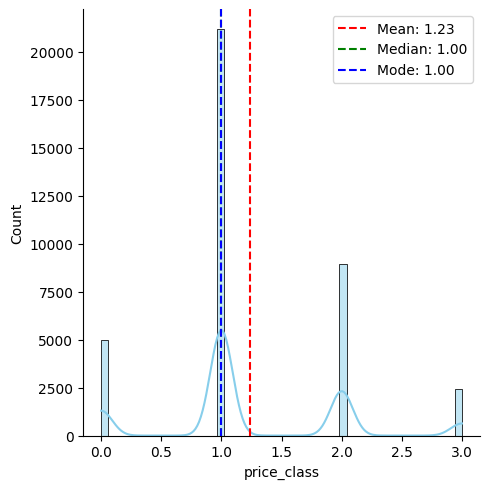

<Figure size 500x500 with 0 Axes>

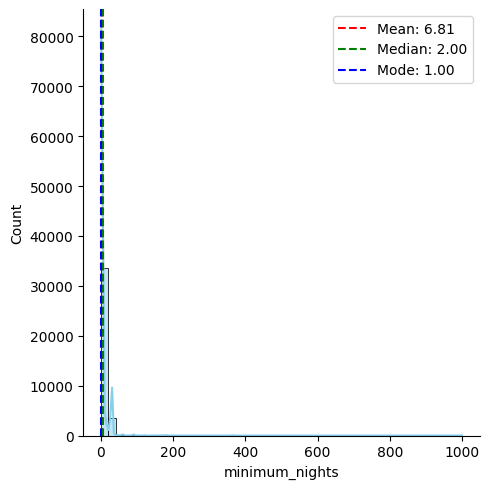

<Figure size 500x500 with 0 Axes>

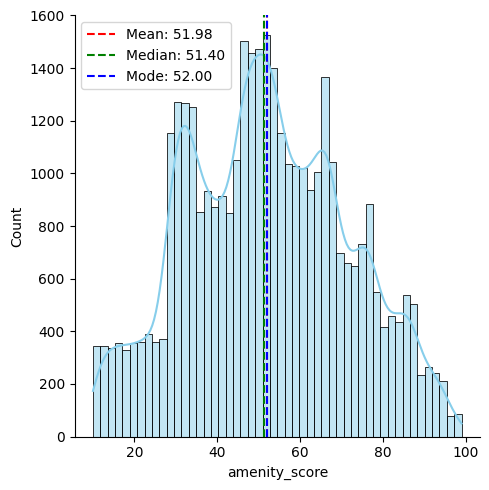

<Figure size 500x500 with 0 Axes>

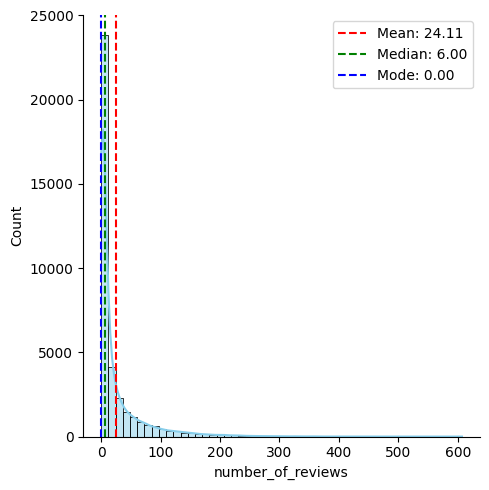

<Figure size 500x500 with 0 Axes>

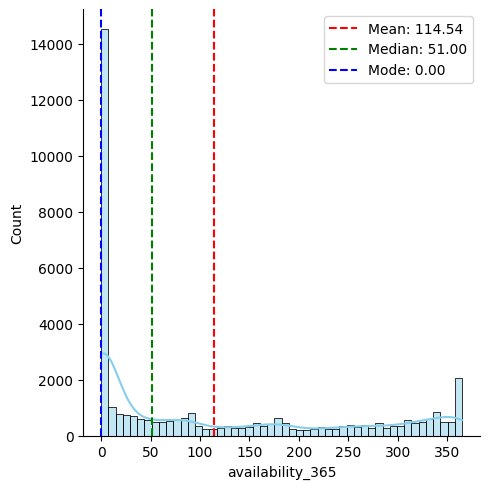

In [164]:

plot_feature_distribution('price_class')
plot_feature_distribution('minimum_nights')

plot_feature_distribution('amenity_score')

plot_feature_distribution('number_of_reviews')

plot_feature_distribution('availability_365')

In [182]:
categorical_col_pipeline = Pipeline(steps=[
    ('mode_impute', SimpleImputer(strategy='most_frequent', add_indicator=True)),
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


log_numerical_col_pipeline = Pipeline(steps=[
    ('median_impute', SimpleImputer(strategy='median', add_indicator=True)),
    ('log_transform', FunctionTransformer(func=np.log1p,)),
    ('scaler', StandardScaler())])

ss_col_pipeline = Pipeline(steps=[
    ('median_impute', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())])
    
    

In [ ]:
categorical_features = ['neighbourhood_group', 'room_type']
log_numerical_features = ['minimum_nights', 'number_of_reviews']
ss_features = ['amenity_score', 'availability_365']

feature_processing = ColumnTransformer(transformers=[
    ('categorical_col_pipeline', categorical_col_pipeline, categorical_features),
    ('log_numerical_col_pipeline', log_numerical_col_pipeline, log_numerical_features),
    ('ss_col_pipeline', ss_col_pipeline, ss_features)
], remainder='passthrough').set_output(transform='pandas')

X = feature_processing.fit_transform(df)
print(X.shape)
print(X.head(1))

y = X['price_class']
X_to_train = X.drop(columns=['price_class'])

['categorical_col_pipeline__neighbourhood_group_Bronx', 'categorical_col_pipeline__neighbourhood_group_Brooklyn', 'categorical_col_pipeline__neighbourhood_group_Manhattan', 'categorical_col_pipeline__neighbourhood_group_Queens', 'categorical_col_pipeline__neighbourhood_group_Staten Island', 'categorical_col_pipeline__room_type_Entire home/apt', 'categorical_col_pipeline__room_type_Private room', 'categorical_col_pipeline__room_type_Shared room', 'categorical_col_pipeline__missingindicator_neighbourhood_group_False', 'categorical_col_pipeline__missingindicator_neighbourhood_group_True', 'categorical_col_pipeline__missingindicator_room_type_False', 'categorical_col_pipeline__missingindicator_room_type_True', 'log_numerical_col_pipeline__minimum_nights', 'log_numerical_col_pipeline__number_of_reviews', 'log_numerical_col_pipeline__missingindicator_minimum_nights', 'log_numerical_col_pipeline__missingindicator_number_of_reviews', 'ss_col_pipeline__amenity_score', 'ss_col_pipeline__availabi

KeyError: 'price_class'

In [ ]:

neumeric_features = ['remainder__minimum_nights', 'remainder__number_of_reviews', 'remainder__amenity_score', 'remainder__availability_365']

num_feat_pipeline = Pipeline(steps=[
    ('simple_imputer', SimpleImputer(strategy='median', add_indicator=True)),
])

col_transformation = ColumnTransformer( [('num_feat_pipeline', num_feat_pipeline, neumeric_features)], remainder='passthrough').set_output(transform='pandas')
df_step_2 = col_transformation.fit_transform(df_step_1)
print(df_step_2.columns)

In [ ]:

# as min night and number of reviews are highly +vs skewed, 
# we will apply log transformation to these features to reduce 
# the skewness 
df_step_2['minimum_nights'] = np.log1p(df_step_2['remainder__minimum_nights'])
df_step_2['number_of_reviews'] = np.log1p(df_step_2['remainder__number_of_reviews'])

# as amenity score is between 0 and 100, we will scale it to be between 0 and 1
df_step_2['amenity_score'] = df_step_2['remainder__amenity_score']/100
df_step_2['availability_365'] = df_step_2['remainder__availability_365']/365

features_to_standardized = ['minimum_nights', 'number_of_reviews', 'amenity_score', 'availability_365']

num_fet_pipeline = Pipeline(steps=[
    ('standard_scaler', StandardScaler()),
    ('missing_indicator', SimpleImputer(strategy='median', fill_value=0))
])

numerical_transformer = ColumnTransformer(transformers=[
    ('num_fet_pipeline', num_fet_pipeline, features_to_standardized)])

df_step_3 = numerical_transformer.fit_transform(df_step_2)



In [ ]:
print(df.describe())
print(df.isna().sum())

In [ ]:
def plot_distribution_by_feature(feature):
    plt.figure(figsize=(10,6))
    sns.countplot(x=feature, hue='price_class', data=df_copy, palette='Set2')
    plt.title(f'Distribution of {feature} by Price Class')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

plot_distribution_by_feature('room_type')
plot_distribution_by_feature('neighbourhood_group')

In [ ]:
def numerical_feature_distribution(feature):
    plt.figure(figsize=(10,6))
    sns.boxplot(x='price_class' , y=feature, data=df_copy, hue='price_class', palette='Set3')
    plt.title(f'Relationship between price class and {feature}')
    plt.xlabel('Price Class')
    plt.ylabel(feature)
    plt.show()

numerical_feature_distribution('amenity_score')
numerical_feature_distribution('number_of_reviews')
numerical_feature_distribution('availability_365')
numerical_feature_distribution('minimum_nights')

In [ ]:
print("correlation marix:")
numerice_features = ['minimum_nights', 'number_of_reviews', 'amenity_score', 'availability_365', 'price_class']
correlation_matrix = df_copy[numerice_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='price_class', y='availability_365', data=df_copy, hue='room_type', palette='Set3')

plt.title('Boxplot of Availability by Room Type and Price Class')
plt.xlabel('Price Class')
plt.ylabel('Availability (365 days)')
plt.show()

In [ ]:

from neural_network import NeuralNetwork
from activation_frunctions import Relu, Softmax

L1_NEURONS = 32
L2_NEURONS = 16
OUTPUT_NEURONS = 4

y = df['price_class'].values
X = df.drop(columns=['price_class']).values
X = X[0:5, :]
print(X.shape)

neuralNetwork = NeuralNetwork(input_data=X)
neuralNetwork.add_layer(num_of_neurons=L1_NEURONS, activation_function=Relu())
neuralNetwork.add_layer(num_of_neurons=L2_NEURONS, activation_function=Relu())
neuralNetwork.add_layer(num_of_neurons=OUTPUT_NEURONS, activation_function=Softmax())
y = neuralNetwork.forward(X)
print(y)

In [ ]:
print(f'unique cities: {df["city"].nunique()}') # for year we will use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset
print(f'unique registered: {df["registered"].nunique()}') # for year we will use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset
print(f'unique body: {df["body"].nunique()}') # for body we must use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset
print(f'unique color: {df["color"].nunique()}')  # for color we must use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset
print(f'unique make: {df["make"].nunique()}')  # for make we must use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset
print(f'unique model: {df["model"].nunique()}')  # for make we must use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset


In [ ]:

# encoding 'registered' column by collapsing rare categories into 'Other'

min_count = 1000
protected = ['Un-Registered']
counts = df['registered'].value_counts()
# print(counts.head(10))

rare_categories = counts[(counts < min_count) & (counts.index.isin(protected)) == False].index
# print(rare_categories)

df['registered_collapsed'] = df['registered'].where(
    df['registered'].isin(rare_categories) == False, 'Other'
)

# print(df['registered_collapsed'].value_counts())

df = pd.get_dummies(df, columns=['registered_collapsed'], prefix='registered', drop_first=True)

# print(ds_encoded.head(5))

In [ ]:

cols_to_encode = ['make', 'model']
target_encoder = TargetEncoder(cols=cols_to_encode, smoothing=10, handle_missing='value', handle_unknown='value')
ds_encoded = target_encoder.fit_transform(ds_encoded, ds_encoded['price'])

print(ds_encoded.head(5))



In [ ]:
X = df.iloc[:, 0:-1].values
y = df.iloc[:, -1].values
print(df.head(5))